# Desafio de Regressão - Insurance.csv

Objetivo: criar um modelo preditivo de regressão para prever `charges` (custos médicos individuais), avaliando a eficácia com métricas estatísticas.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

RANDOM_STATE = 42
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [3]:
# Ajuste o caminho se necessário
df = pd.read_csv("insurance.csv")

print("Base carregada com sucesso.")
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")

Base carregada com sucesso.
Dimensões: 1338 linhas x 7 colunas


In [4]:
display(df.head())
display(df.sample(5, random_state=RANDOM_STATE))
print("\nTipos das colunas:")
display(df.dtypes)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


,age,sex,bmi,children,smoker,region,charges
764,45,female,25.175,2,no,northeast,9095.06825
887,36,female,30.020,0,no,northwest,5272.17580
890,64,female,26.885,0,yes,northwest,29330.98315
1293,46,male,25.745,3,no,northwest,9301.89355
259,19,male,31.920,0,yes,northwest,33750.29180



Tipos das colunas:


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [5]:
print("Valores nulos por coluna:")
display(df.isnull().sum())

print("\nDuplicados na base:", df.duplicated().sum())

print("\nResumo estatístico (numéricas):")
display(df.describe().T)

print("\nResumo estatístico (categóricas):")
display(df.describe(include="object").T)

Valores nulos por coluna:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Duplicados na base: 1

Resumo estatístico (numéricas):


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801



Resumo estatístico (categóricas):


,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


In [ ]:
data_dict = {
    "age": "idade do beneficiário principal",
    "sex": "gênero",
    "bmi": "índice de massa corporal (IMC)",
    "children": "número de filhos/dependentes cobertos",
    "smoker": "se a pessoa é fumante (yes/no)",
    "region": "região residencial (northeast, northwest, southeast, southwest)",
    "charges": "custo médico individual cobrado pelo seguro"
}
display(pd.DataFrame.from_dict(data_dict, orient="index", columns=["Descrição"]))

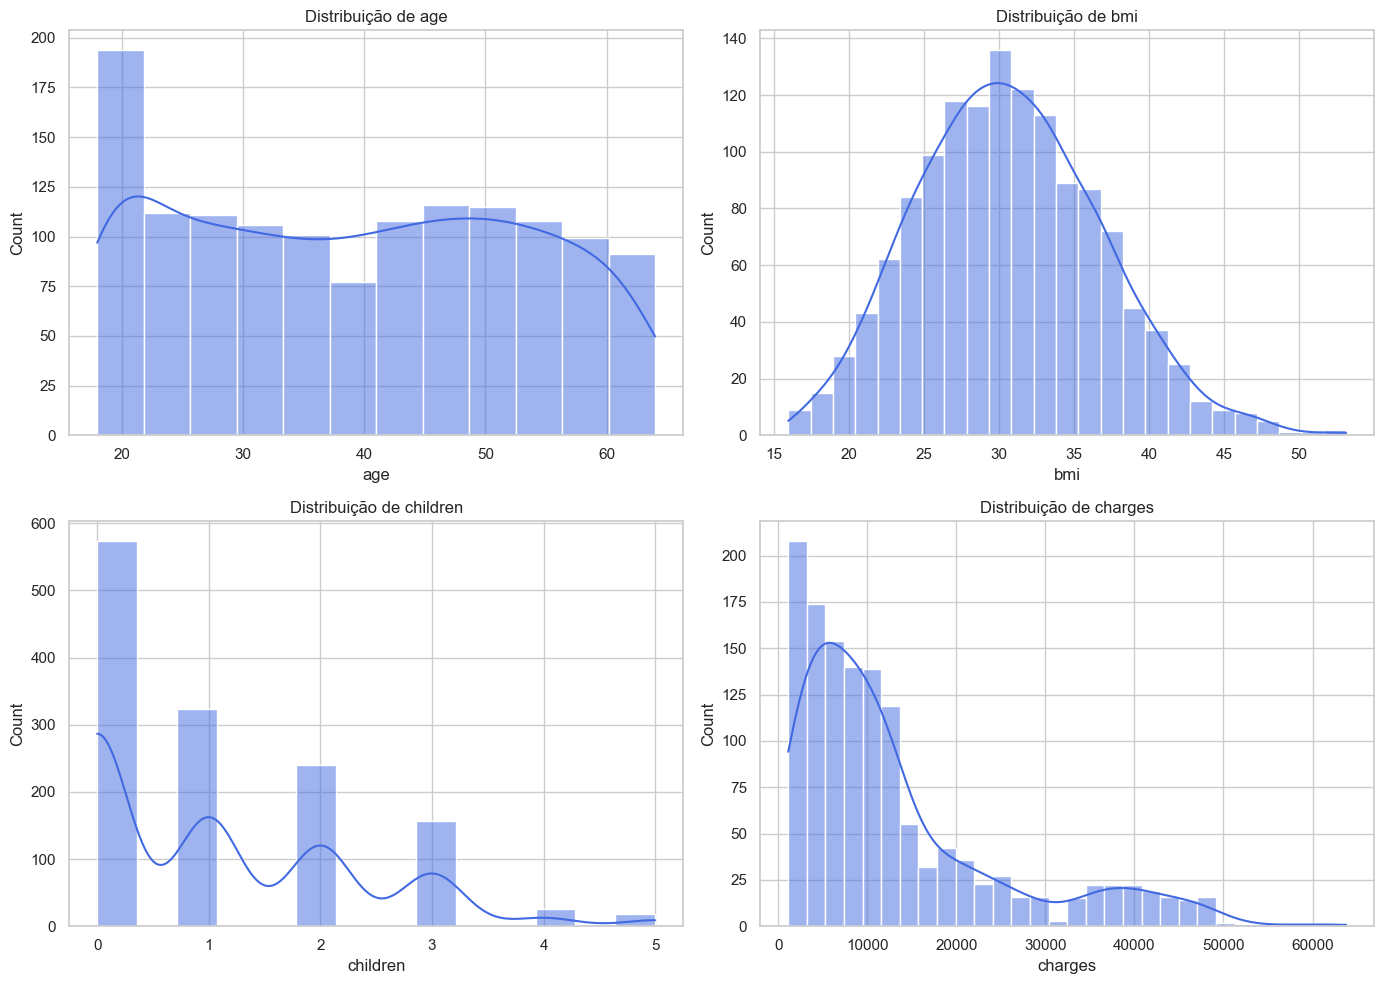

In [6]:
num_cols = ["age", "bmi", "children", "charges"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="royalblue")
    axes[i].set_title(f"Distribuição de {col}")

plt.tight_layout()
plt.show()

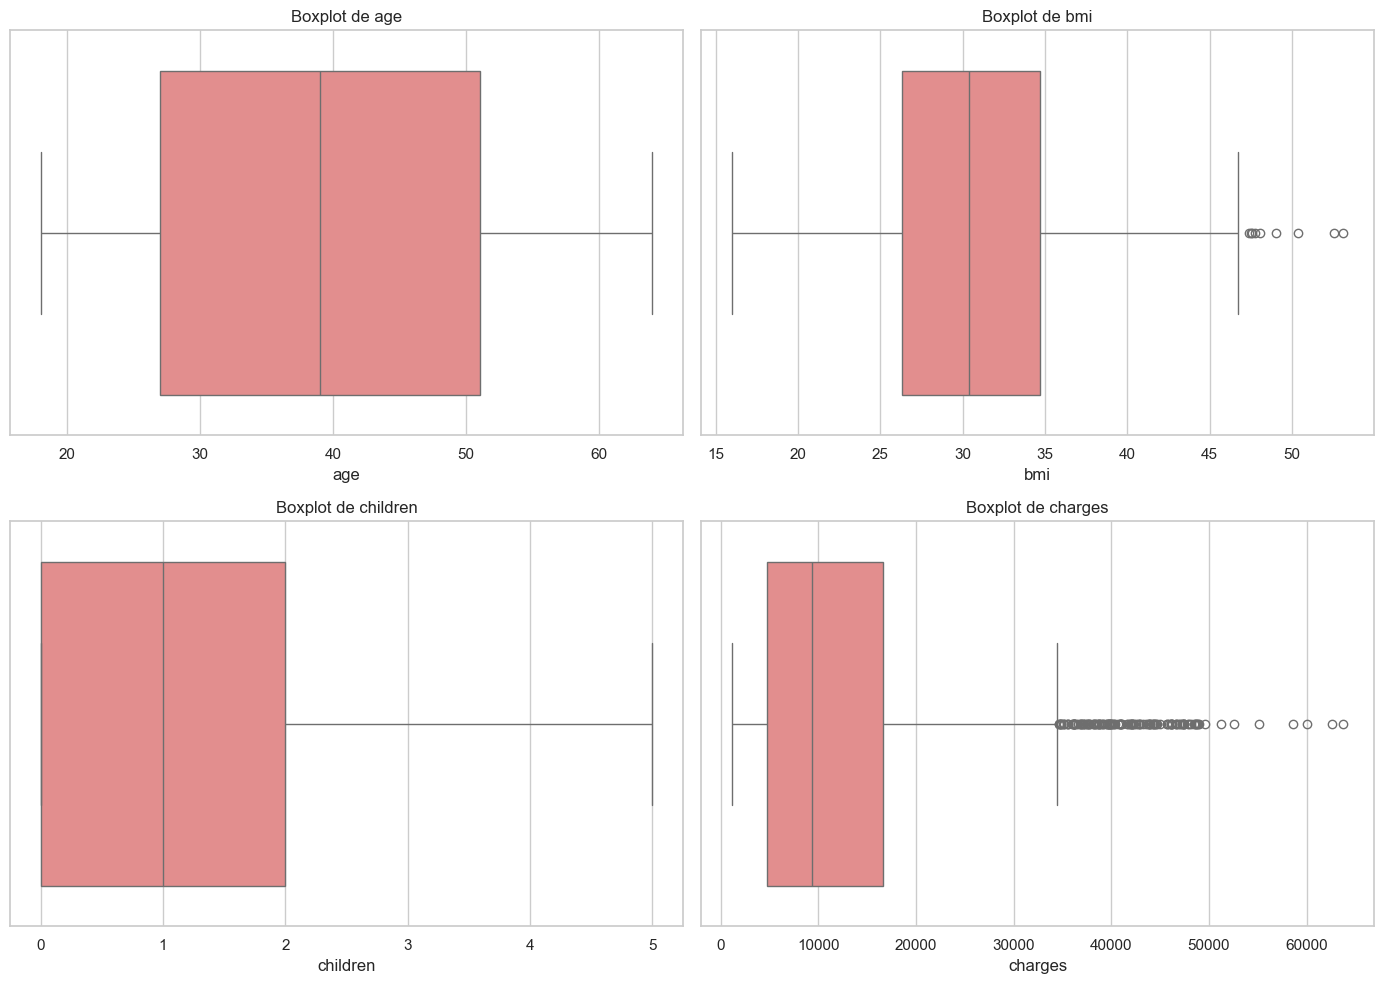

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

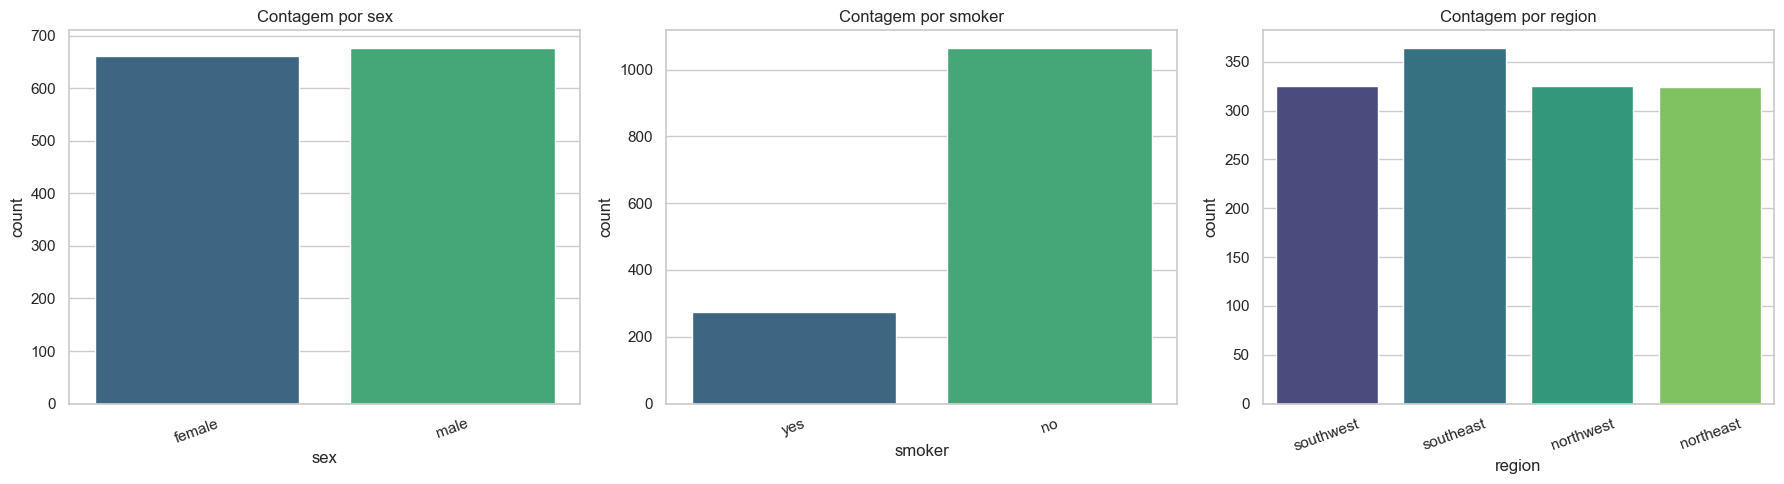

In [8]:
cat_cols = ["sex", "smoker", "region"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Contagem por {col}")
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

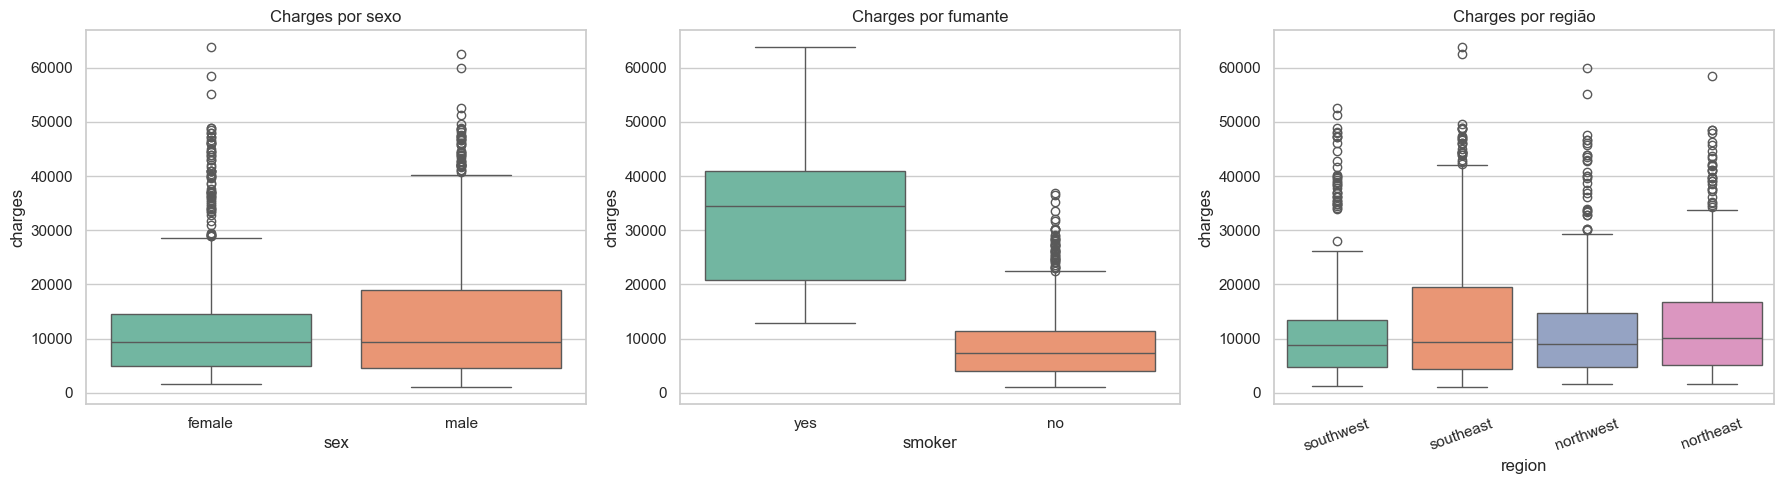

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="sex", y="charges", ax=axes[0], palette="Set2")
axes[0].set_title("Charges por sexo")

sns.boxplot(data=df, x="smoker", y="charges", ax=axes[1], palette="Set2")
axes[1].set_title("Charges por fumante")

sns.boxplot(data=df, x="region", y="charges", ax=axes[2], palette="Set2")
axes[2].set_title("Charges por região")
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

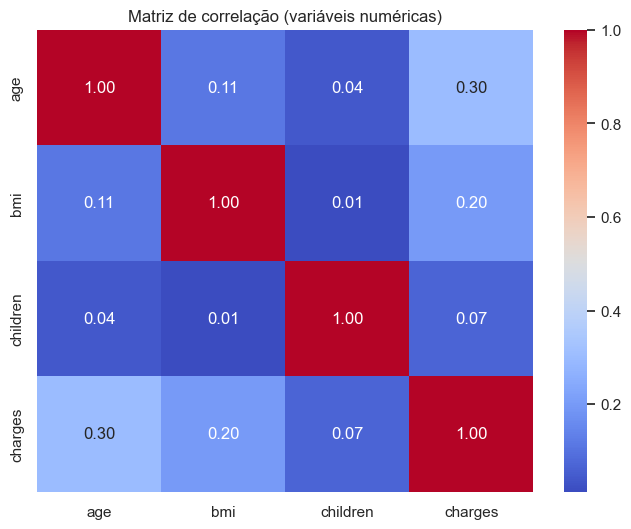

In [10]:
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlação (variáveis numéricas)")
plt.show()

In [11]:
X = df.drop(columns=["charges"])
y = df["charges"]

numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Divisão treino/teste realizada.")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

Divisão treino/teste realizada.
X_train: (1070, 6) | X_test: (268, 6)


In [12]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.001, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE)
}

results = []
predictions_test = {}

In [13]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions_test[model_name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="r2", n_jobs=-1)

    results.append({
        "Modelo": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2_teste": r2,
        "R2_cv_medio": cv_scores.mean(),
        "R2_cv_std": cv_scores.std()
    })

results_df = pd.DataFrame(results).sort_values(by="R2_teste", ascending=False).reset_index(drop=True)
display(results_df)

,Modelo,MAE,RMSE,R2_teste,R2_cv_medio,R2_cv_std
0,GradientBoosting,2443.483262,4329.570011,0.879257,0.849297,0.027974
1,RandomForest,2553.609066,4587.882508,0.864420,0.829974,0.025452
2,LinearRegression,4181.194474,5796.284659,0.783593,0.738853,0.031060
3,Lasso,4181.195498,5796.285412,0.783593,0.738853,0.031060
4,Ridge,4193.195353,5800.464938,0.783281,0.738843,0.031041


In [14]:
best_model_name = results_df.loc[0, "Modelo"]
print(f"Melhor modelo com base no R² de teste: {best_model_name}")

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", models[best_model_name])
])

best_pipeline.fit(X_train, y_train)
best_pred = best_pipeline.predict(X_test)

print("\nMétricas finais do melhor modelo:")
print(f"MAE : {mean_absolute_error(y_test, best_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, best_pred)):.2f}")
print(f"R²  : {r2_score(y_test, best_pred):.4f}")

Melhor modelo com base no R² de teste: GradientBoosting

Métricas finais do melhor modelo:
MAE : 2443.48
RMSE: 4329.57
R²  : 0.8793


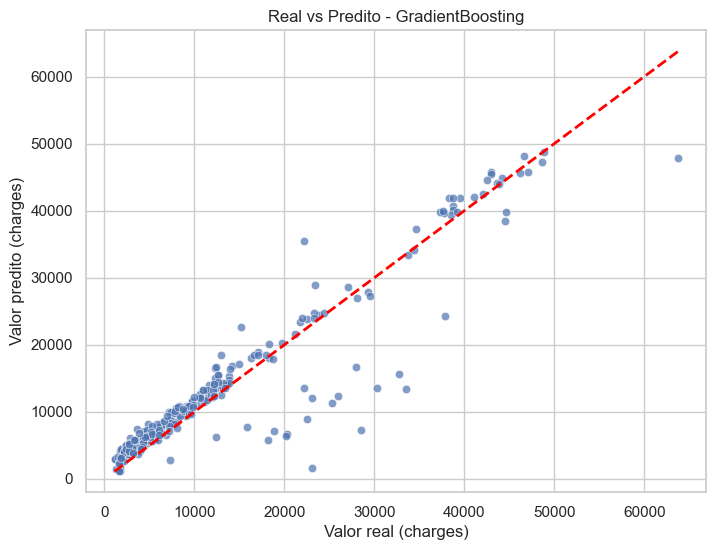

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=best_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", linewidth=2)
plt.xlabel("Valor real (charges)")
plt.ylabel("Valor predito (charges)")
plt.title(f"Real vs Predito - {best_model_name}")
plt.show()

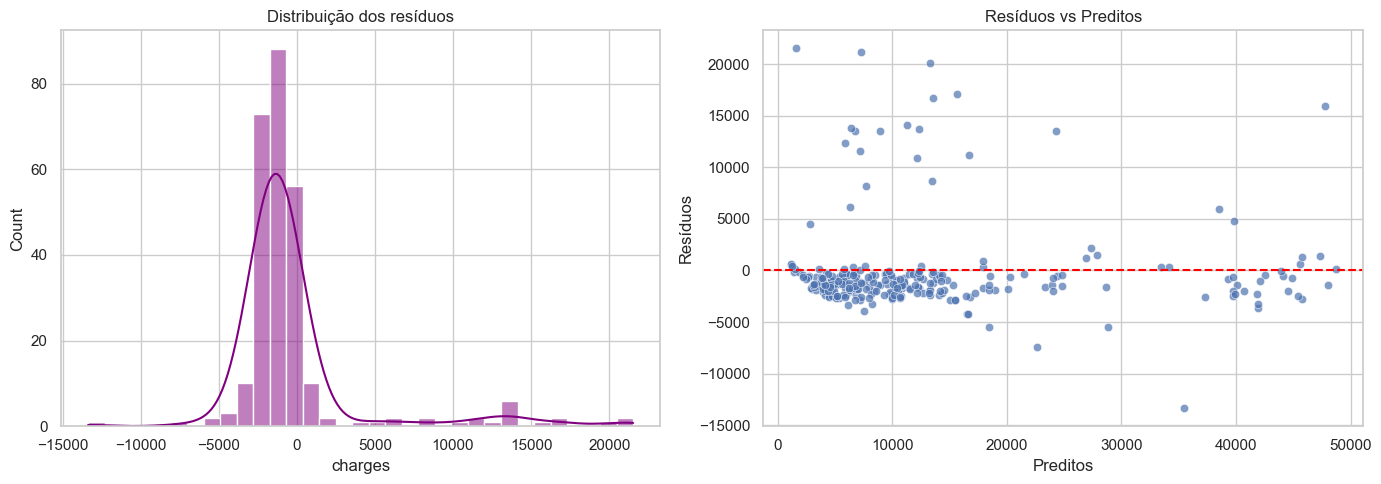

In [16]:
residuos = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuos, kde=True, ax=axes[0], color="purple")
axes[0].set_title("Distribuição dos resíduos")

sns.scatterplot(x=best_pred, y=residuos, ax=axes[1], alpha=0.7)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Resíduos vs Preditos")
axes[1].set_xlabel("Preditos")
axes[1].set_ylabel("Resíduos")

plt.tight_layout()
plt.show()

In [17]:
novo_cliente = pd.DataFrame([{
    "age": 40,
    "sex": "female",
    "bmi": 28.5,
    "children": 2,
    "smoker": "no",
    "region": "southeast"
}])

pred_novo = best_pipeline.predict(novo_cliente)[0]
print("Exemplo de previsão para novo cliente:")
display(novo_cliente)
print(f"Valor previsto de charges: ${pred_novo:,.2f}")

Exemplo de previsão para novo cliente:


,age,sex,bmi,children,smoker,region
0,40,female,28.5,2,no,southeast


Valor previsto de charges: $7,979.43


## Conclusão

- Foi desenvolvido um modelo preditivo de regressão para estimar custos médicos (`charges`).
- O pipeline incluiu padronização de variáveis numéricas e `OneHotEncoding` para variáveis categóricas.
- Foram comparados múltiplos algoritmos e selecionado o melhor com base no **R²** no conjunto de teste.
- As métricas **MAE**, **RMSE** e **R²** foram usadas para comprovar a eficácia do modelo.
- A análise exploratória indica que ser fumante (`smoker`) tende a impactar significativamente o custo médico.